This is a notebook I'm preparing while working through a [course](https://matteoacrossi.github.io/oqs-jupyterbook/) on simulating Open Quantum Systems using Qiskit. 

This would serve as a nice introduction to using Qiskit for someone who knows a lot about oqs and wants to learn 
- Basics of quantum circuit and gates
- Running jobs on a real quantum computer and hence basics of error mitigation that entails

*The error mitigation part in the actual course website is slightly outdated, so replaced with current **Qiskit Experiments** package*

In [45]:
# Importing relevant packages

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Pauli

# %matplotlib inline

# Maximally Entangled $|\Psi^{-}\rangle$ state

Initial:  |00\rangle
After X(0):  |01\rangle
After X(1):  |11\rangle
After H(0): \frac{\sqrt{2}}{2} |10\rangle- \frac{\sqrt{2}}{2} |11\rangle
After CNOT(0, 1): - \frac{\sqrt{2}}{2} |01\rangle+\frac{\sqrt{2}}{2} |10\rangle


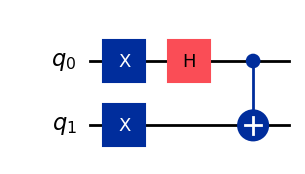

In [46]:
# Generating a maximally entangled Bell state

# # Setup
# You prepare two qubits (Q0 and Q1, say) 
# Initialise a circuit with two of them
q = QuantumRegister(2, name='q')
qc = QuantumCircuit(q)

# # Adding gates come next and we'll also make sure it works
# We will print out the statevector after each operation
state0 = Statevector.from_instruction(qc)
print(f"Initial: {state0.draw('latex_source')}")

# X on both Q0 and Q1
qc.x(q[0])
state1 = Statevector.from_instruction(qc)
print(f"After X(0): {state1.draw('latex_source')}")
qc.x(q[1])
state2 = Statevector.from_instruction(qc)
print(f"After X(1): {state2.draw('latex_source')}")


# H on Q0
qc.h(q[0])
state3 = Statevector.from_instruction(qc)
print(f"After H(0): {state3.draw('latex_source')}")

# CNOT on Q0 and Q1
qc.cx(q[0], q[1])
state4 = Statevector.from_instruction(qc)
print(f"After CNOT(0, 1): {state4.draw('latex_source')}")

# Draw the full progress
qc.draw(output='mpl') 

Since we'll need the maximally entangled $\Psi^{+}$ state multiple times in this analysis let's write a function which takes two qubits and a quantum circuit and returns a quantum circuit which produces a Bell state $\Psi^{+}$ between them

In [47]:
def psi_plus_bell_state(qc: QuantumCircuit, q0: int, q1: int) -> QuantumCircuit:
    '''
    Function for psi_plus_bell_state.
    Applies gates to quantum circuit to create a Psi-plus Bell state.
    
    Parameters
    ----------
    qc: QuantumCircuit 
        The quantum circuit object
    q0: int
        The control qubit index
    q1: int
        The target qubit index
        
    Returns
    -------
    QuantumCircuit
        The modified quantum circuit 
    '''    
    # X on Q1 --- |01> 
    qc.x(q1)
    
    # H on Q0 --- (|0> + |1>)|1>
    qc.h(q0)
    
    # CNOT on Q0 and Q1 --- |01> + |10>
    qc.cx(q0, q1)
    
    return qc

## Exercise: 2.1.1
Consider the following circuit


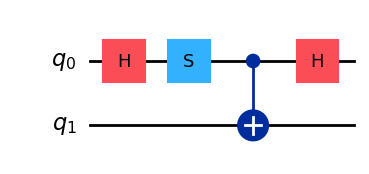

In [48]:
# Quantum register
q = QuantumRegister(2, name='q')

# Quantum circuit
entangled = QuantumCircuit(q)

# Entangled state
entangled.h(q[0])
entangled.s(q[0])
entangled.cx(q[0], q[1])
entangled.h(q[0])

# Draw circuit
entangled.draw(output='mpl')


- Write the resulting two-qubit quantum state $\rho_{q_0,q_1}=|\psi\rangle\langle\psi|$.



In [49]:
rho = DensityMatrix.from_instruction(qc)
print(f"Density Matrix")
rho.draw("Latex")

Density Matrix


<IPython.core.display.Latex object>

- Compute the partial trace to obtain the reduced density matrix $\rho_{q_0}$ of $q_0$.


In [50]:
ptrace = partial_trace(rho, [0])
print(r"Partial trace $\rho_{q0}$")
ptrace.draw("Latex")


Partial trace $\rho_{q0}$


<IPython.core.display.Latex object>

- Determine the Bloch vector x of $\rho_{q_0}$

In [51]:
# Calculating the components of Bloch vector 
r_x = ptrace.expectation_value(Pauli('X'))
r_y = ptrace.expectation_value(Pauli('Y'))
r_z = ptrace.expectation_value(Pauli('Z'))

print(f"Bloch vector x-component: {r_x.real}")
print(f"Full Bloch vector: ({r_x.real}, {r_y.real}, {r_z.real})")

Bloch vector x-component: 0.0
Full Bloch vector: (0.0, 0.0, 0.0)


- The Bloch vectors $\mathbf{x}$ and $\mathbf{y}$ of partial traces $\rho$ and $\sigma$ of a qubit serves as a measure of indistinguishability $0 \leq D[\rho,\sigma] \leq 1$, where $D[\rho,\sigma] = \frac 12 \, |\mathbf{x} - \mathbf{y}|$.

- Maximal Entanglement thus gives $D[\rho,\sigma] = 0$.

# Quantum Channels

- A quantum operation is a quantum channel.
- It can be an effect of measurement, which projects / maps the state of the system into a different state.
- But it's more vague than that. Any evolution or noise or measurement come under the umbrella of channels.
- If it doesn't map onto a physical state (pure or mixed) - it's not a channel but a map.

# Exercise 2.2.1

Consider the following circuit implementing a channel on qubit $q_0$ (we assume $q_1$ to be initially in state $|0\rangle$)


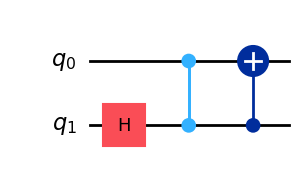

In [52]:
# Quantum register
q = QuantumRegister(2, name='q')

# Quantum circuit
channel = QuantumCircuit(q)
 
channel.h(q[1])
channel.cz(q[0], q[1])
channel.cx(q[1], q[0])

# Draw circuit
channel.draw(output='mpl')

- Calculate the outcoming state of $q_0$ for the following incoming states: 

    (a) $a |0\rangle + b |1\rangle$ with $|a|^2 + |b|^2 = 1$

In [53]:
# We'll start with a rather naive way of doing this and then make it a bit sophisticated

# Since we've used these gates in the qc in question, we won't be using the same
# However, we can initialise the state in this prep_circuit and then compose it with original channel
prep_channel = QuantumCircuit(2)

# Initialise q0 as (a |0> + b |1>) 
# Normalisation a and b can change as long as normalisation works
a = b = 1 / np.sqrt(2)
prep_channel.initialize([a, b], 0)

# We've not defined any gate yet, so the full state
full_state = Statevector.from_instruction(prep_channel)

print('Initial State')
full_state.draw("Latex")

Initial State


<IPython.core.display.Latex object>

**Comment**: This shows Qiskit convention: Writes the state backwards as $|q_{1}q_{0}\rangle$.

In [54]:
final_channel = prep_channel.compose(channel)

# Final state
print("Final State")
Statevector(final_channel).draw("Latex")

Final State


<IPython.core.display.Latex object>

(b) $p_1 |+ \rangle \langle +| + p_2 |- \rangle \langle - |$, where $p_1 + p_2 = 1$

In [55]:
# Lesson: You're better off using statevector.from_label and then density matrices all through
plus = Statevector.from_label('+')
minus = Statevector.from_label('-')
zero = Statevector.from_label('0')
one = Statevector.from_label('1')

# p1 = p2 = 0.5
# rho_q0 = p1 * DensityMatrix(plus) + p2 * DensityMatrix(minus)

# rho_q1 = DensityMatrix(zero)


- Verify that the channel is completely positive using proposition 2 (consider a third ancillary qubit q2 maximally entangled with q0).




- Determine the Kraus representation of the channel.
